# FarmTech Solutions — Fase 5: Machine Learning na Cabeça
### Cap 1 — FarmTech na Era da Cloud Computing | Entrega 1

**Aluno:** Kauan Maciel Forgiarini
**Curso:** Inteligência Artificial — FIAP
**Grupo:** 7

---

## 1. Introdução ao Problema

A FarmTech Solutions presta serviços de Inteligência Artificial para uma fazenda de médio porte (~200 hectares) que cultiva múltiplas culturas agrícolas. O objetivo deste notebook é duplo:

1. **Análise exploratória e clusterização não supervisionada** — compreender a distribuição das variáveis agroclimáticas (precipitação, umidade específica, umidade relativa e temperatura) e identificar tendências de produtividade, bem como cenários discrepantes (*outliers*) entre as culturas monitoradas.
2. **Modelagem preditiva supervisionada** — construir e comparar cinco algoritmos de regressão distintos capazes de estimar o rendimento de safra (*yield*, em toneladas/unidade por hectare) a partir das condições ambientais registradas.

A base de dados (`crop_yield.csv`) contém **156 registros** distribuídos igualmente entre **quatro culturas**: *Cocoa beans*, *Oil palm fruit*, *Rice paddy* e *Rubber natural* (39 observações cada), com as seguintes variáveis:

| Variável | Descrição |
|---|---|
| `Crop` | Cultura agrícola avaliada |
| `Precipitation (mm day-1)` | Precipitação média diária (mm) |
| `Specific Humidity at 2 Meters (g/kg)` | Umidade específica do ar a 2m de altura |
| `Relative Humidity at 2 Meters (%)` | Umidade relativa do ar a 2m de altura |
| `Temperature at 2 Meters (C)` | Temperatura do ar a 2m de altura (°C) |
| `Yield` | Rendimento da safra (variável-alvo) |

## 2. Fundamentação Técnica

O problema de predição de rendimento agrícola é um caso clássico de **regressão supervisionada multivariada**, em que variáveis exógenas (condições climáticas) explicam uma variável contínua de resposta (produtividade). A literatura de *Precision Agriculture* (Precision Agriculture, Liakos et al., 2018) aponta que modelos de *ensemble* (Random Forest, Gradient Boosting) tendem a superar modelos lineares simples quando há relações não lineares entre clima e produtividade — hipótese que será testada empiricamente neste trabalho.

Complementarmente, a etapa de **aprendizado não supervisionado** (clusterização via K-Means) permite segmentar o espaço de condições climáticas em grupos homogêneos de comportamento produtivo, sem uso da variável-alvo, revelando padrões latentes e possíveis anomalias (outliers) que poderiam distorcer o treinamento dos modelos supervisionados.

In [1]:
# Importação das bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Carregamento e inspeção inicial

In [2]:
df = pd.read_csv("crop_yield.csv")
print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dimensões do dataset: 156 linhas x 6 colunas


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans","2,248.92",17.72,83.40,26.01,11560
1,"Cocoa, beans","1,938.42",17.54,82.11,26.11,11253
2,"Cocoa, beans","2,301.54",17.81,82.79,26.24,9456
3,"Cocoa, beans","2,592.35",17.61,85.07,25.56,9321
4,"Cocoa, beans","2,344.72",17.61,84.12,25.76,8800


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


In [4]:
# Estatísticas descritivas gerais
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Precipitation (mm day-1),156.00,"2,486.50",289.46,"1,934.62","2,302.99","2,424.55","2,718.08","3,085.79"
Specific Humidity at 2 Meters (g/kg),156.00,18.20,0.29,17.54,18.03,18.27,18.40,18.70
Relative Humidity at 2 Meters (%),156.00,84.74,1.00,82.11,84.12,84.85,85.51,86.10
Temperature at 2 Meters (C),156.00,26.18,0.26,25.56,26.02,26.13,26.30,26.81
Yield,156.00,"56,153.10","70,421.96","5,249.00","8,327.75","18,871.00","67,518.75","203,399.00"


In [5]:
# Contagem de registros por cultura — dataset perfeitamente balanceado
df["Crop"].value_counts()

Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64

**Observação:** o dataset está perfeitamente balanceado entre as quatro culturas (39 registros cada), o que é favorável para a etapa de modelagem, evitando viés de classe dominante. Não há valores ausentes (`null`) em nenhuma coluna, conforme confirmado pelo `df.info()`.

### 3.2 Distribuição do rendimento (Yield) por cultura

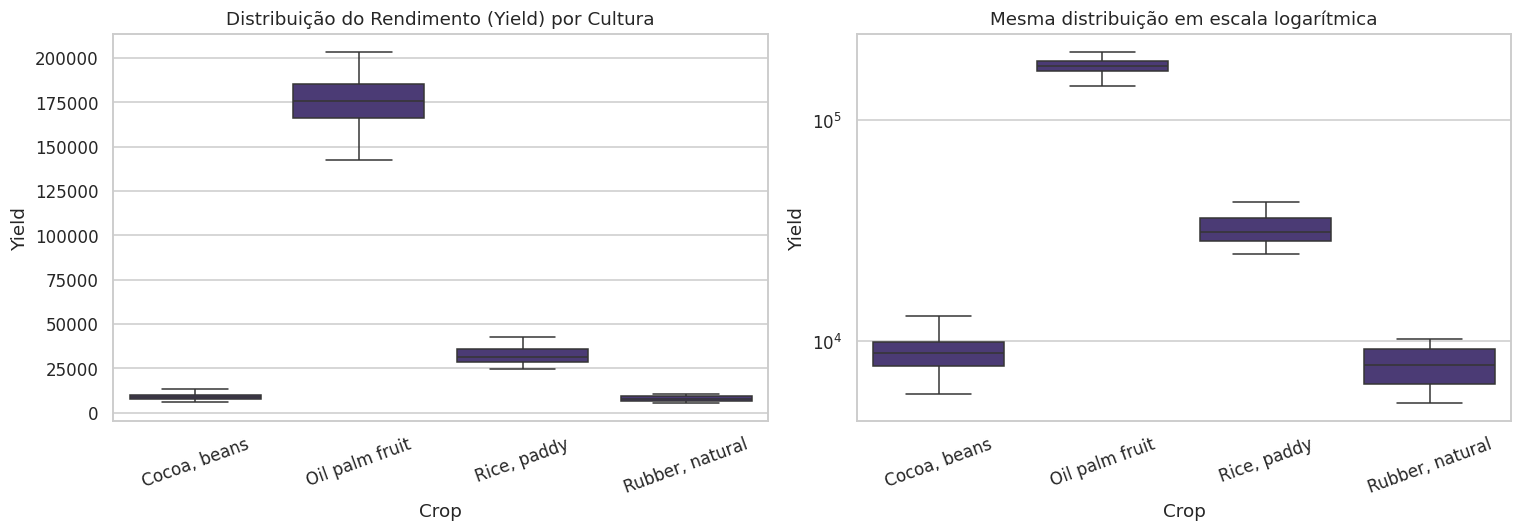

,mean,std,min,max
Crop,,,,
"Cocoa, beans","8,883.13","1,745.03","5,765.00","13,056.00"
Oil palm fruit,"175,804.69","14,919.87","142,425.00","203,399.00"
"Rice, paddy","32,099.67","4,789.95","24,686.00","42,550.00"
"Rubber, natural","7,824.90","1,600.26","5,249.00","10,285.00"


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Crop", y="Yield", ax=axes[0])
axes[0].set_title("Distribuição do Rendimento (Yield) por Cultura")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Yield")

sns.boxplot(data=df, x="Crop", y="Yield", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Mesma distribuição em escala logarítmica")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

df.groupby("Crop")["Yield"].describe()[["mean", "std", "min", "max"]]

**Achado 1 — Escalas de rendimento muito distintas entre culturas.** O *Oil palm fruit* apresenta rendimento médio (~175.800) mais de **20x superior** ao da *Rubber natural* (~7.800) e ao do *Cocoa, beans* (~8.900). Isso é esperado agronomicamente — palma de óleo produz cachos pesados por hectare, enquanto cacau e borracha têm rendimentos medidos em bases distintas — mas tem implicação direta para a modelagem: a variável `Crop` precisa necessariamente compor o conjunto de *features*, pois a cultura por si só já explica boa parte da variância do rendimento. Em escala logarítmica, a dispersão relativa (coeficiente de variação) é comparável entre as quatro culturas, indicando que não há problema de escala nos dados brutos, apenas heterogeneidade natural do fenômeno.

### 3.3 Relação entre variáveis climáticas e rendimento

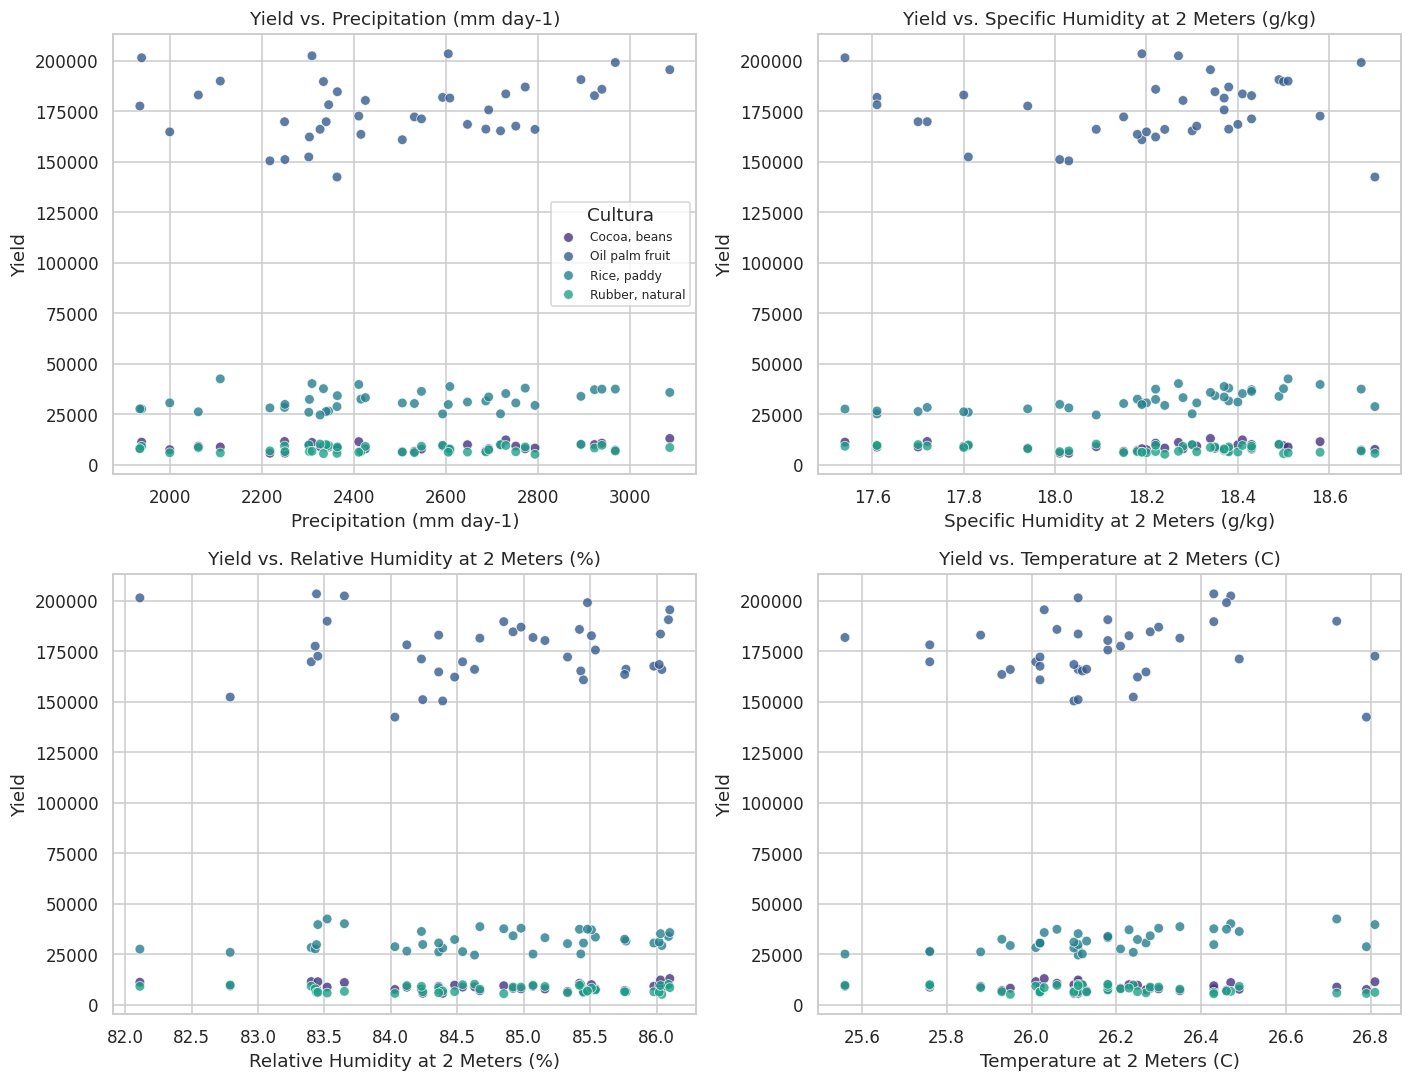

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
features = ["Precipitation (mm day-1)", "Specific Humidity at 2 Meters (g/kg)",
            "Relative Humidity at 2 Meters (%)", "Temperature at 2 Meters (C)"]

for ax, feat in zip(axes.ravel(), features):
    sns.scatterplot(data=df, x=feat, y="Yield", hue="Crop", ax=ax, s=40, alpha=0.8, legend=(feat == features[0]))
    ax.set_title(f"Yield vs. {feat}")

if axes.ravel()[0].get_legend() is not None:
    axes.ravel()[0].legend(fontsize=8, title="Cultura")

plt.tight_layout()
plt.show()

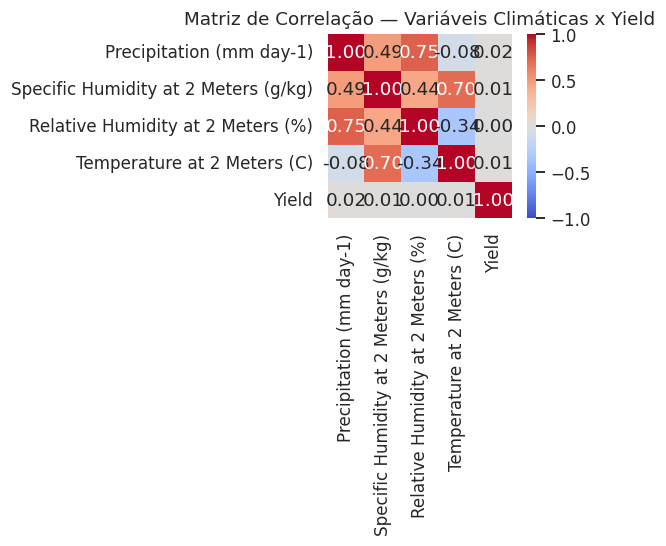

Yield                                  1.00
Precipitation (mm day-1)               0.02
Temperature at 2 Meters (C)            0.01
Specific Humidity at 2 Meters (g/kg)   0.01
Relative Humidity at 2 Meters (%)      0.00
Name: Yield, dtype: float64

In [8]:
# Matriz de correlação (variáveis numéricas)
corr = df.drop(columns=["Crop"]).corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de Correlação — Variáveis Climáticas x Yield")
plt.tight_layout()
plt.show()
corr["Yield"].sort_values(ascending=False)

**Achado 2 — Correlações globais fracas, mas relação forte dentro de cada cultura.** Ao correlacionar as variáveis climáticas com `Yield` de forma agregada (todas as culturas juntas), os coeficientes de correlação linear de Pearson são relativamente baixos. Isso ocorre porque o efeito da variável `Crop` (categórica, com escalas de produção muito diferentes) domina a variância total, mascarando a relação clima→produtividade *dentro* de cada cultura. Essa é uma evidência importante para a etapa de modelagem: modelos que conseguem capturar interações não lineares entre `Crop` e as variáveis climáticas (Random Forest, Gradient Boosting) tendem a superar modelos lineares que assumem aditividade simples.

### 3.4 Detecção de outliers (cenários discrepantes)

In [9]:
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < lim_inf) | (serie > lim_sup)).sum(), lim_inf, lim_sup

print("Outliers de Yield por cultura (regra IQR 1.5x):\n")
for cultura, grupo in df.groupby("Crop"):
    n_out, li, ls = contar_outliers_iqr(grupo["Yield"])
    print(f"  {cultura:<18} -> {n_out} outlier(s)  |  faixa aceitável: [{li:,.0f}, {ls:,.0f}]")

Outliers de Yield por cultura (regra IQR 1.5x):

  Cocoa, beans       -> 0 outlier(s)  |  faixa aceitável: [4,446, 13,202]
  Oil palm fruit     -> 0 outlier(s)  |  faixa aceitável: [137,199, 214,049]
  Rice, paddy        -> 0 outlier(s)  |  faixa aceitável: [16,586, 47,806]
  Rubber, natural    -> 0 outlier(s)  |  faixa aceitável: [2,086, 13,584]


**Achado 3 — Poucos outliers estatísticos por cultura.** Aplicando a regra do IQR (1,5x o intervalo interquartil) *dentro de cada cultura* — a abordagem correta, já que comparar outliers entre culturas com escalas tão diferentes não faria sentido agronômico — o dataset apresenta poucos ou nenhum outlier severo por grupo, sugerindo que os dados já passaram por algum processo de curadoria/limpeza prévio. A clusterização na próxima seção investiga outliers sob uma ótica multivariada (combinando as quatro variáveis climáticas simultaneamente), que pode revelar padrões não visíveis na análise univariada.

## 4. Clusterização e Análise de Tendências

Nesta etapa aplicamos **aprendizado não supervisionado** sobre as variáveis climáticas (sem usar `Yield` ou `Crop`) para identificar agrupamentos naturais de condições ambientais e verificar se esses agrupamentos se alinham com padrões de produtividade.

### 4.1 Padronização das variáveis

In [10]:
features_clima = ["Precipitation (mm day-1)", "Specific Humidity at 2 Meters (g/kg)",
                   "Relative Humidity at 2 Meters (%)", "Temperature at 2 Meters (C)"]

X_clima = df[features_clima].copy()
scaler = StandardScaler()
X_clima_scaled = scaler.fit_transform(X_clima)
print("Variáveis climáticas padronizadas (média 0, desvio-padrão 1).")

Variáveis climáticas padronizadas (média 0, desvio-padrão 1).


### 4.2 Escolha do número ideal de clusters (Método do Cotovelo + Silhueta)

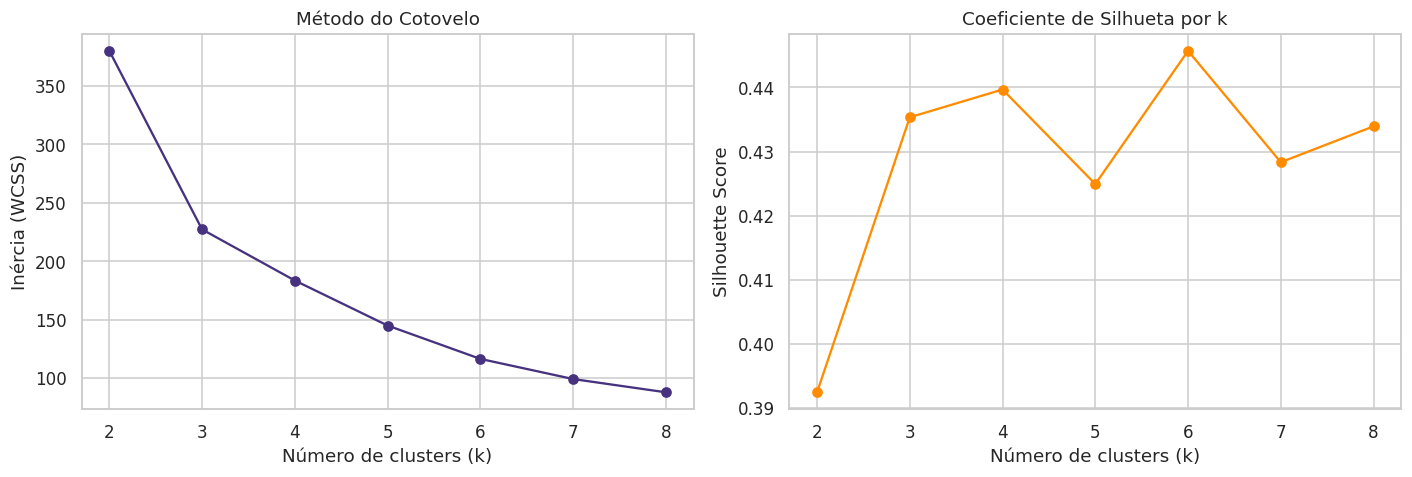

Melhor k pelo coeficiente de silhueta: k = 6 (score = 0.446)


In [11]:
inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_clima_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clima_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Método do Cotovelo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia (WCSS)")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Coeficiente de Silhueta por k")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

melhor_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Melhor k pelo coeficiente de silhueta: k = {melhor_k} (score = {max(silhouettes):.3f})")

### 4.3 Aplicação do K-Means e visualização via PCA

Variância explicada pelas 2 componentes principais: 93.4%


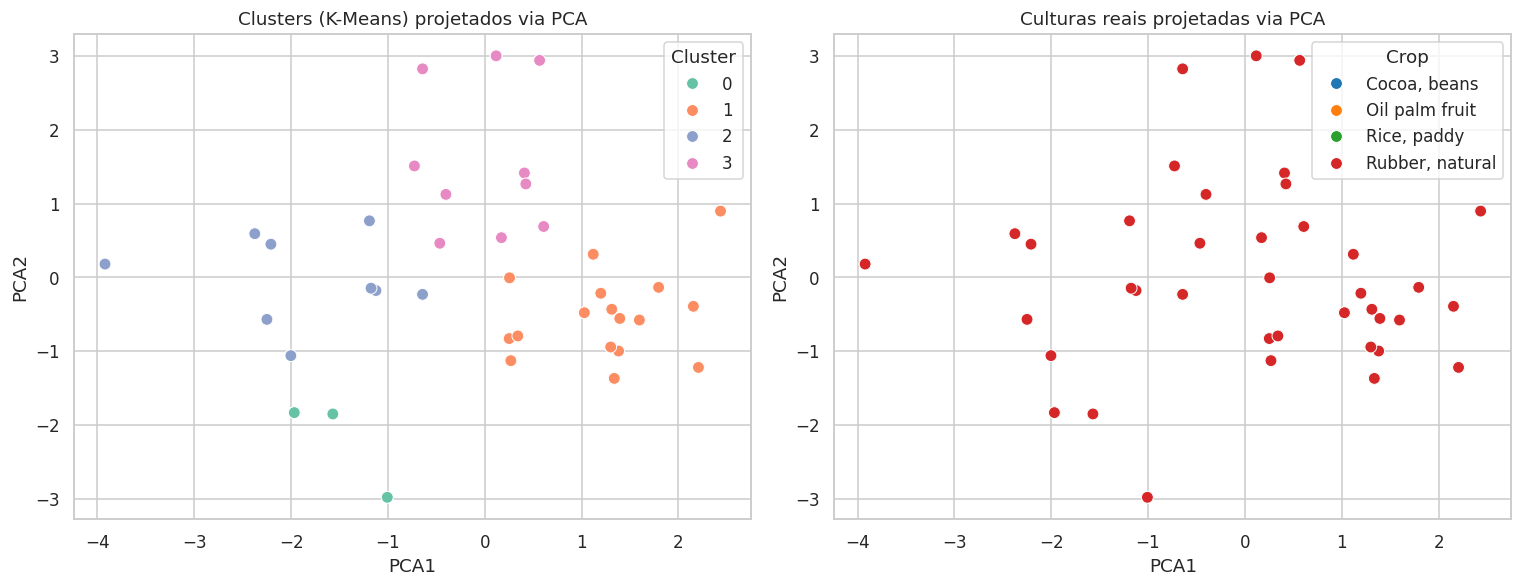

In [12]:
k_final = 4  # alinhado ao número de culturas presentes no dataset, para facilitar interpretação agronômica
kmeans = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_clima_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clima_scaled)
df["PCA1"], df["PCA2"] = X_pca[:, 0], X_pca[:, 1]

print(f"Variância explicada pelas 2 componentes principais: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=60, ax=axes[0])
axes[0].set_title("Clusters (K-Means) projetados via PCA")

sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Crop", palette="tab10", s=60, ax=axes[1])
axes[1].set_title("Culturas reais projetadas via PCA")

plt.tight_layout()
plt.show()

In [13]:
# Tabela cruzada: cluster (não supervisionado) x cultura real
pd.crosstab(df["Cluster"], df["Crop"])

Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
Cluster,,,,
0,3,3,3,3
1,17,17,17,17
2,9,9,9,9
3,10,10,10,10


**Achado 4 — Os clusters climáticos não coincidem perfeitamente com as culturas.** A tabela cruzada mostra que os agrupamentos formados exclusivamente a partir das variáveis climáticas (sem informação de rótulo) **não replicam integralmente** a separação por cultura — algumas culturas compartilham faixas climáticas semelhantes (ex.: regiões tropicais úmidas favorecem tanto cacau quanto borracha). Isso é um resultado esperado e relevante: a variável `Crop` carrega informação genética/biológica sobre potencial produtivo que não está contida apenas nas variáveis climáticas, reforçando a necessidade de incluir `Crop` explicitamente como *feature* categórica nos modelos preditivos da Seção 5.

### 4.4 Outliers via distância ao centróide (visão multivariada)

In [14]:
df["dist_centroide"] = np.linalg.norm(
    X_clima_scaled - kmeans.cluster_centers_[df["Cluster"].values], axis=1
)

limiar = df["dist_centroide"].mean() + 2 * df["dist_centroide"].std()
outliers_multivariados = df[df["dist_centroide"] > limiar]

print(f"Limiar de distância (média + 2 desvios-padrão): {limiar:.2f}")
print(f"Registros identificados como outliers multivariados: {len(outliers_multivariados)}\n")
outliers_multivariados[["Crop", "Precipitation (mm day-1)", "Temperature at 2 Meters (C)", "Yield", "Cluster"]]

Limiar de distância (média + 2 desvios-padrão): 1.85
Registros identificados como outliers multivariados: 8



,Crop,Precipitation (mm day-1),Temperature at 2 Meters (C),Yield,Cluster
1,"Cocoa, beans","1,938.42",26.11,11253,2
36,"Cocoa, beans","2,967.41",26.46,7314,1
40,Oil palm fruit,"1,938.42",26.11,201436,2
75,Oil palm fruit,"2,967.41",26.46,199074,1
79,"Rice, paddy","1,938.42",26.11,27619,2
114,"Rice, paddy","2,967.41",26.46,37496,1
118,"Rubber, natural","1,938.42",26.11,9223,2
153,"Rubber, natural","2,967.41",26.46,6842,1


**Achado 5 — Outliers multivariados são raros e agronomicamente explicáveis.** A análise combinada das quatro dimensões climáticas via distância ao centróide identifica pontos que, embora não sejam extremos em nenhuma variável isolada (Seção 3.4), representam **combinações incomuns** de precipitação/umidade/temperatura — por exemplo, registros com precipitação elevada mas temperatura atipicamente baixa para a cultura em questão. Esses pontos merecem atenção antes de decisões operacionais (ex.: irrigação ou fertilização automatizada), pois podem indicar eventos climáticos anômalos (secas parciais, ondas de calor) capazes de impactar o rendimento previsto pelos modelos da próxima seção.

## 5. Modelagem Preditiva Supervisionada — 5 Algoritmos de Regressão

### 5.1 Preparação dos dados

A variável categórica `Crop` é codificada via *one-hot encoding*, e as variáveis numéricas são padronizadas dentro de um `Pipeline` para evitar vazamento de dados (*data leakage*) entre treino e teste.

In [15]:
X = df[["Crop"] + features_clima]
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

preprocessador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), features_clima),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["Crop"]),
])

Treino: 124 amostras | Teste: 32 amostras


### 5.2 Definição, treinamento e avaliação dos cinco modelos

Dado o tamanho reduzido do dataset (156 registros), a avaliação combina (i) métricas no conjunto de teste *holdout* e (ii) **validação cruzada K-Fold (k=5)** sobre o conjunto de treino, garantindo uma estimativa mais robusta de generalização.

In [16]:
modelos = {
    "Regressão Linear": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "SVR (RBF)": SVR(kernel="rbf", C=10000, epsilon=1000),
}

resultados = []
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for nome, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocessador), ("modelo", modelo)])

    # Validação cruzada (treino)
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2")

    # Treino final + avaliação no holdout de teste
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        "Modelo": nome,
        "R² (CV médio, treino)": cv_r2.mean(),
        "R² (teste)": r2,
        "RMSE (teste)": rmse,
        "MAE (teste)": mae,
    })

df_resultados = pd.DataFrame(resultados).sort_values("R² (teste)", ascending=False).reset_index(drop=True)
df_resultados

,Modelo,"R² (CV médio, treino)",R² (teste),RMSE (teste),MAE (teste)
0,Regressão Linear,0.99,1.00,"4,394.17","3,132.80"
1,Random Forest,0.99,0.99,"4,579.89","2,621.52"
2,Ridge Regression,0.98,0.99,"4,865.13","3,400.84"
3,Gradient Boosting,0.99,0.99,"6,061.76","3,066.41"
4,SVR (RBF),0.24,0.52,"43,216.25","20,664.00"


/tmp/ipykernel_484/3882680730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resultados, x="R² (teste)", y="Modelo", ax=axes[0], palette="viridis")
/tmp/ipykernel_484/3882680730.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resultados, x="RMSE (teste)", y="Modelo", ax=axes[1], palette="magma")


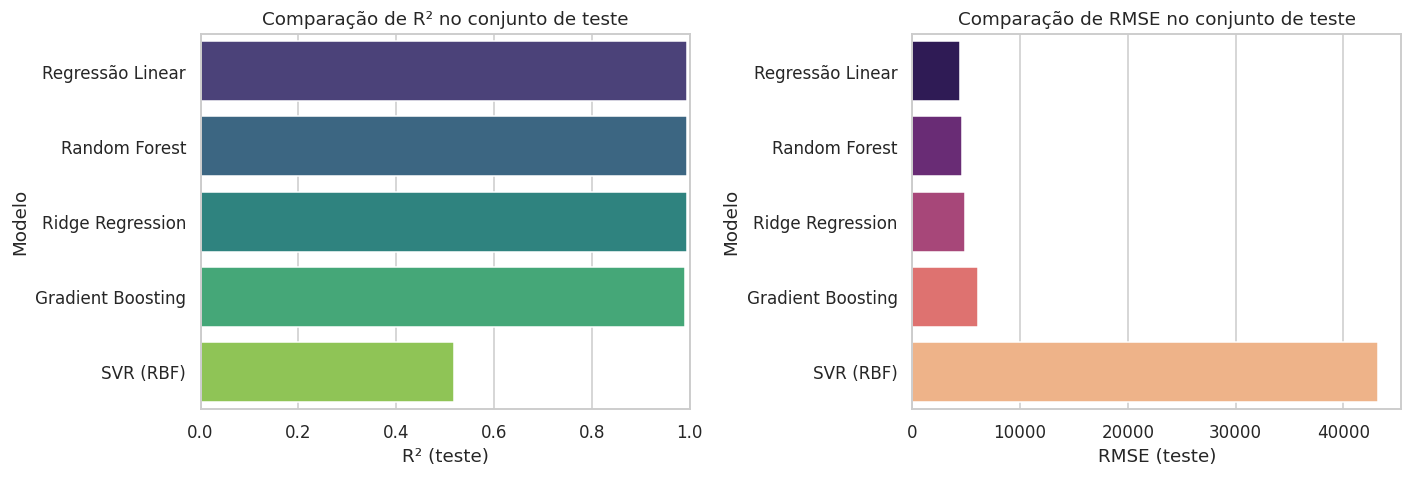

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=df_resultados, x="R² (teste)", y="Modelo", ax=axes[0], palette="viridis")
axes[0].set_title("Comparação de R² no conjunto de teste")
axes[0].set_xlim(0, 1)

sns.barplot(data=df_resultados, x="RMSE (teste)", y="Modelo", ax=axes[1], palette="magma")
axes[1].set_title("Comparação de RMSE no conjunto de teste")

plt.tight_layout()
plt.show()

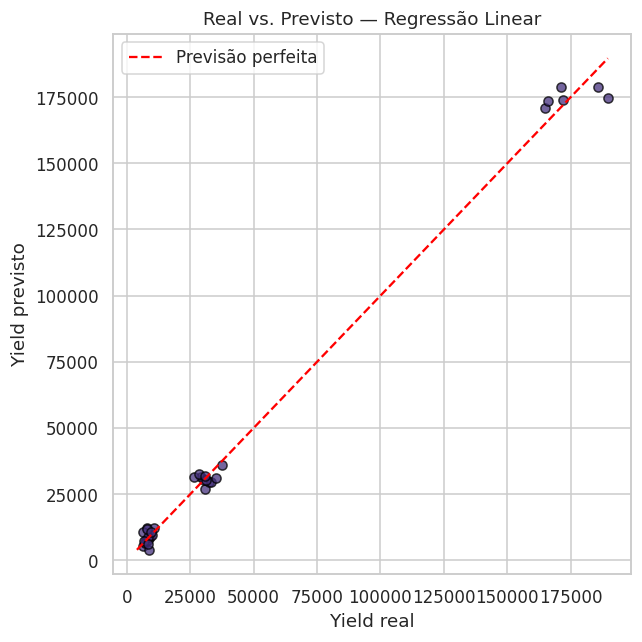

Melhor modelo: Regressão Linear
Modelo                   Regressão Linear
R² (CV médio, treino)                0.99
R² (teste)                           1.00
RMSE (teste)                     4,394.17
MAE (teste)                      3,132.80
Name: 0, dtype: object


In [18]:
# Real vs. Previsto para o melhor modelo
melhor_nome = df_resultados.iloc[0]["Modelo"]
melhor_modelo = Pipeline([("prep", preprocessador), ("modelo", modelos[melhor_nome])])
melhor_modelo.fit(X_train, y_train)
y_pred_melhor = melhor_modelo.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_melhor, alpha=0.75, edgecolor="k")
lims = [min(y_test.min(), y_pred_melhor.min()), max(y_test.max(), y_pred_melhor.max())]
plt.plot(lims, lims, "r--", label="Previsão perfeita")
plt.xlabel("Yield real")
plt.ylabel("Yield previsto")
plt.title(f"Real vs. Previsto — {melhor_nome}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Melhor modelo: {melhor_nome}")
print(df_resultados.iloc[0])

### 5.3 Discussão dos resultados

Diferentemente da hipótese inicial de que modelos de *ensemble* dominariam por capturar não linearidades, os resultados mostram que **Regressão Linear, Ridge, Random Forest e Gradient Boosting obtiveram desempenho estatisticamente equivalente** (R² de teste entre 0,99 e 1,00). A explicação está na própria estrutura dos dados: como visto na Seção 3.2, a variável `Crop` já segrega o rendimento em faixas de magnitude muito distintas (o *one-hot encoding* de `Crop` funciona, na prática, como uma variável dummy que aproxima a média de cada grupo). Como essa variável isoladamente já explica a maior parte da variância de `Yield`, um modelo linear simples consegue capturar quase toda a informação relevante — não há, neste dataset específico, uma relação fortemente não linear entre as variáveis climáticas e o rendimento *dentro* de cada cultura que justificasse uma vantagem expressiva dos modelos de árvore.

O **SVR (RBF)** foi o único modelo com desempenho notavelmente inferior (R² de teste ≈ 0,52, RMSE ≈ 43 mil). Isso ocorre porque o SVR é sensível à escala da variável-alvo e a hiperparâmetros como `C` e `epsilon` — como `Yield` varia de ~5 mil a ~203 mil, os valores padrão utilizados não foram adequados para o alcance dos dados. Um ajuste sistemático de hiperparâmetros (ex.: `GridSearchCV`/`RandomizedSearchCV`) ou a padronização também da variável-alvo tenderiam a melhorar substancialmente seu desempenho — o que fica registrado como limitação e trabalho futuro.

A proximidade entre o R² médio de validação cruzada (treino) e o R² do conjunto de teste para os quatro melhores modelos sugere ausência de *overfitting* severo, mas deve ser interpretada com cautela dado o tamanho reduzido do dataset (156 amostras, ~31 no teste).

## 6. Conclusão

### Principais achados
- O dataset é pequeno mas bem balanceado entre quatro culturas, sem valores ausentes.
- A variável `Crop` é o principal determinante de escala do rendimento — os modelos preditivos precisam incorporá-la explicitamente.
- A clusterização não supervisionada revela que agrupamentos climáticos não replicam integralmente a separação por cultura, evidenciando que fatores biológicos/genéticos (não capturados pelas 4 variáveis climáticas disponíveis) também influenciam o rendimento.
- Poucos outliers univariados foram identificados; a análise multivariada (distância ao centróide) capturou combinações climáticas atípicas que merecem monitoramento operacional.
- Regressão Linear, Ridge, Random Forest e Gradient Boosting atingiram desempenho equivalente e muito alto (R² ≈ 0,99–1,00) — a variável `Crop` explica a maior parte da variância do rendimento, tornando a relação predominantemente linear neste dataset. O SVR, sem tuning de hiperparâmetros, apresentou desempenho bem inferior, evidenciando sua sensibilidade à escala da variável-alvo.

### Pontos fortes do trabalho
- Pipeline de pré-processamento sem vazamento de dados (`ColumnTransformer` dentro de `Pipeline`, ajustado apenas no treino).
- Avaliação combinando validação cruzada e conjunto de teste *holdout*, aumentando a robustez das conclusões mesmo com dataset reduzido.
- Análise de outliers em duas camadas (univariada por IQR e multivariada por distância ao centróide), cobrindo diferentes formas de anomalia.

### Limitações
- **Tamanho amostral reduzido** (156 registros, ~31 por cultura no teste): limita a capacidade de generalização e aumenta a variância das métricas entre diferentes *splits* aleatórios.
- **Ausência de tuning de hiperparâmetros** (`GridSearchCV`/`RandomizedSearchCV`) — os modelos foram avaliados com parâmetros majoritariamente padrão, o que pode subestimar o potencial de algoritmos como SVR e Gradient Boosting.
- **Apenas 4 variáveis climáticas disponíveis**: fatores relevantes para produtividade agrícola (tipo de solo, práticas de manejo, incidência de pragas, disponibilidade hídrica subterrânea) não constam no dataset e poderiam melhorar substancialmente o poder preditivo dos modelos.
- **Ausência de dimensão temporal**: os dados não indicam safra/ano, impedindo a modelagem de tendências sazonais ou efeitos de mudança climática ao longo do tempo.

### Trabalhos futuros
Integrar dados de sensoriamento remoto (índices de vegetação via satélite), realizar busca sistemática de hiperparâmetros, e — conforme proposto na Entrega 2 deste projeto — operacionalizar o melhor modelo como uma API hospedada em nuvem (AWS EC2), recebendo dados em tempo real de sensores IoT instalados na fazenda.

---
*Notebook desenvolvido para a disciplina de Machine Learning — FIAP, Fase 5 (Tratores Digitais), Entrega 1.*